In [57]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams

rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [58]:
data = pd.read_csv('/content/creditcard.csv', sep=',')
print("Original dataset loaded successfully. Displaying the first 5 rows:")
display(data.head())

# Perform sampling directly after loading to ensure consistency
data = data.sample(frac=0.1, random_state=1)
print(f"\nSampled dataset shape: {data.shape}")

Original dataset loaded successfully. Displaying the first 5 rows:


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1



Sampled dataset shape: (69, 16)


In [59]:
print("\n--- Data Info ---")
data.info()


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 69 entries, 666 to 69
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  69 non-null     int64  
 1   A1          69 non-null     int64  
 2   A2          69 non-null     float64
 3   A3          69 non-null     float64
 4   A4          69 non-null     int64  
 5   A5          69 non-null     int64  
 6   A6          69 non-null     int64  
 7   A7          69 non-null     float64
 8   A8          69 non-null     int64  
 9   A9          69 non-null     int64  
 10  A10         69 non-null     int64  
 11  A11         69 non-null     int64  
 12  A12         69 non-null     int64  
 13  A13         69 non-null     int64  
 14  A14         69 non-null     int64  
 15  Class       69 non-null     int64  
dtypes: float64(3), int64(13)
memory usage: 9.2 KB


In [60]:
print("\n--- Missing Values ---")
display(data.isnull().values.any())


--- Missing Values ---


np.False_


--- Class Distribution ---


/tmp/ipykernel_3212/3332880441.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort=True)


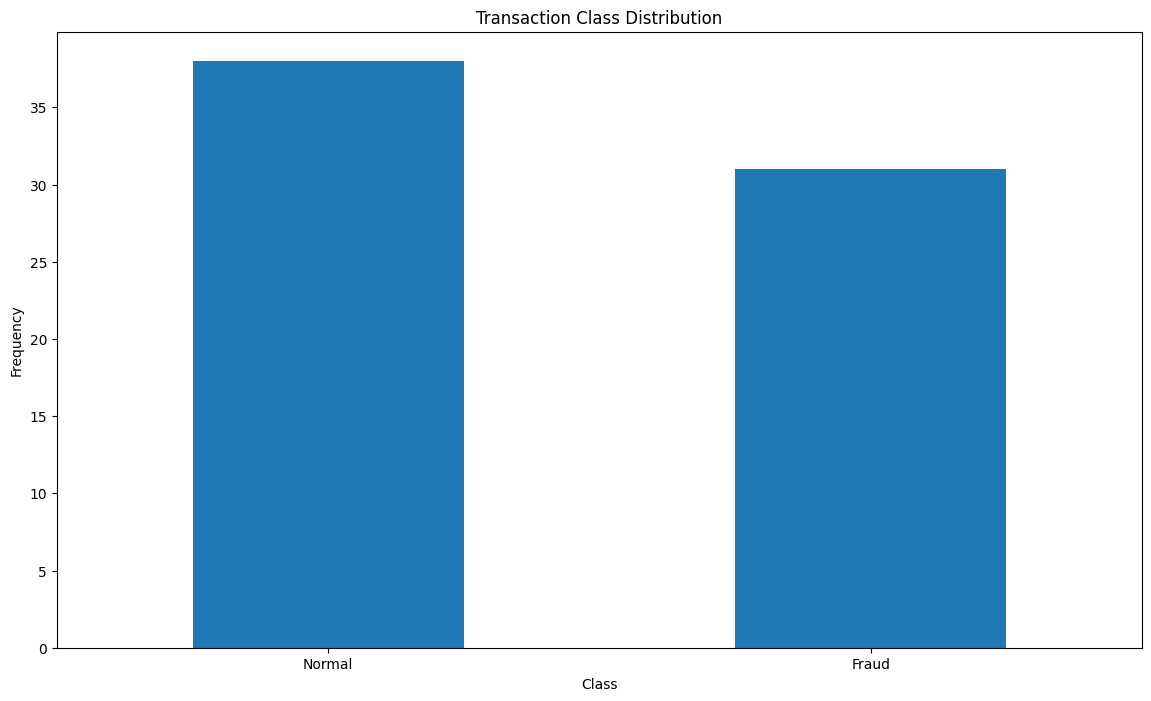

In [61]:
print("\n--- Class Distribution ---")
count_classes = pd.value_counts(data['Class'], sort=True)
count_classes.plot(kind='bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [62]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]
print(f"Fraudulent Transactions Shape: {fraud.shape}")
print(f"Normal Transactions Shape: {normal.shape}")

Fraudulent Transactions Shape: (38, 16)
Normal Transactions Shape: (31, 16)


In [63]:
print("\n--- Fraudulent Transactions Amount Description (using A2 as placeholder) ---")
display(fraud.A2.describe())


--- Fraudulent Transactions Amount Description (using A2 as placeholder) ---


,A2
count,38.000000
mean,33.808421
std,14.082076
min,16.080000
25%,22.460000
50%,28.915000
75%,41.375000
max,67.750000


In [64]:
print("\n--- Normal Transactions A2 Description (placeholder for Amount) ---")
display(normal.A2.describe())


--- Normal Transactions A2 Description (placeholder for Amount) ---


,A2
count,31.000000
mean,31.004839
std,12.703193
min,15.830000
25%,22.710000
50%,27.830000
75%,34.165000
max,74.830000


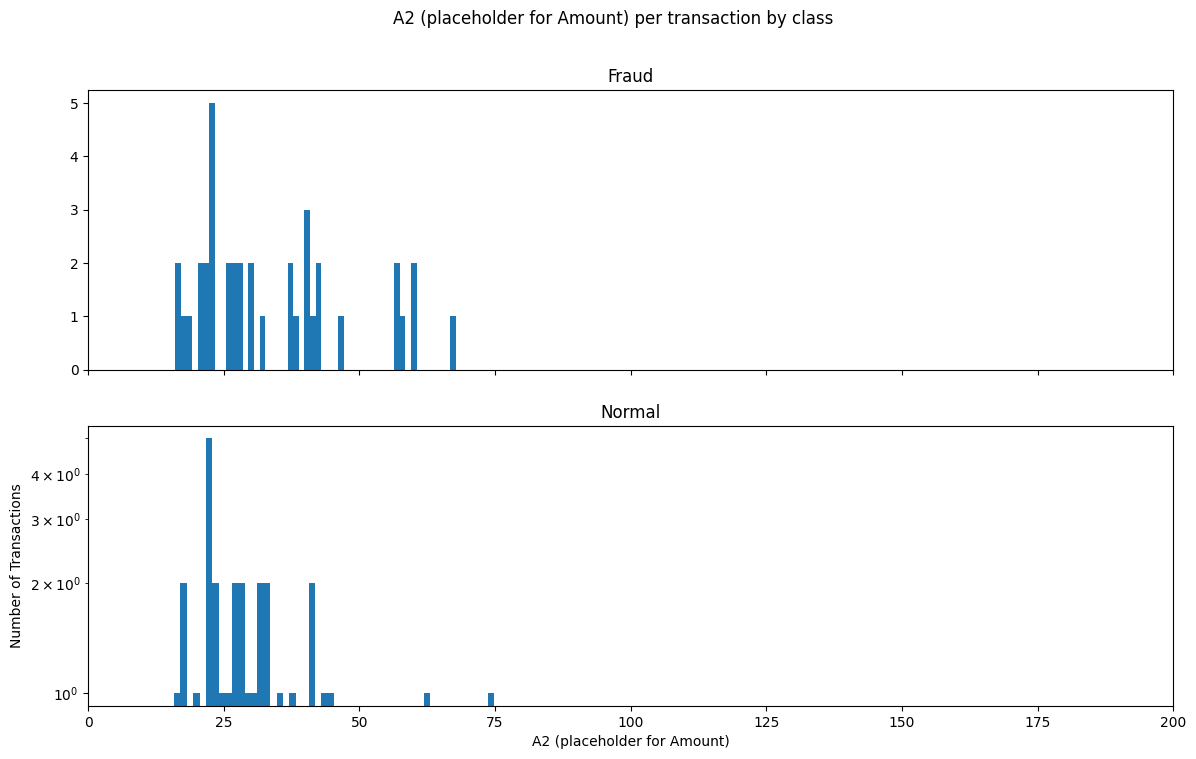

In [65]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('A2 (placeholder for Amount) per transaction by class')
bins = 50 # The number of bins can affect the "roughness". More bins can make a histogram appear jagged if data is sparse.
ax1.hist(fraud.A2, bins=bins)
ax1.set_title('Fraud')
ax2.hist(normal.A2, bins=bins)
ax2.set_title('Normal')
plt.xlabel('A2 (placeholder for Amount)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 200))
plt.yscale('log') # A logarithmic y-axis can amplify the visual differences between bins, making the plot appear "rougher".
plt.show()

# To make the histogram appear smoother, you could try:
# 1. Reducing the number of bins (e.g., bins=20 or bins=30).
# 2. Using a Kernel Density Estimate (KDE) plot instead of a histogram for a smoothed distribution curve.

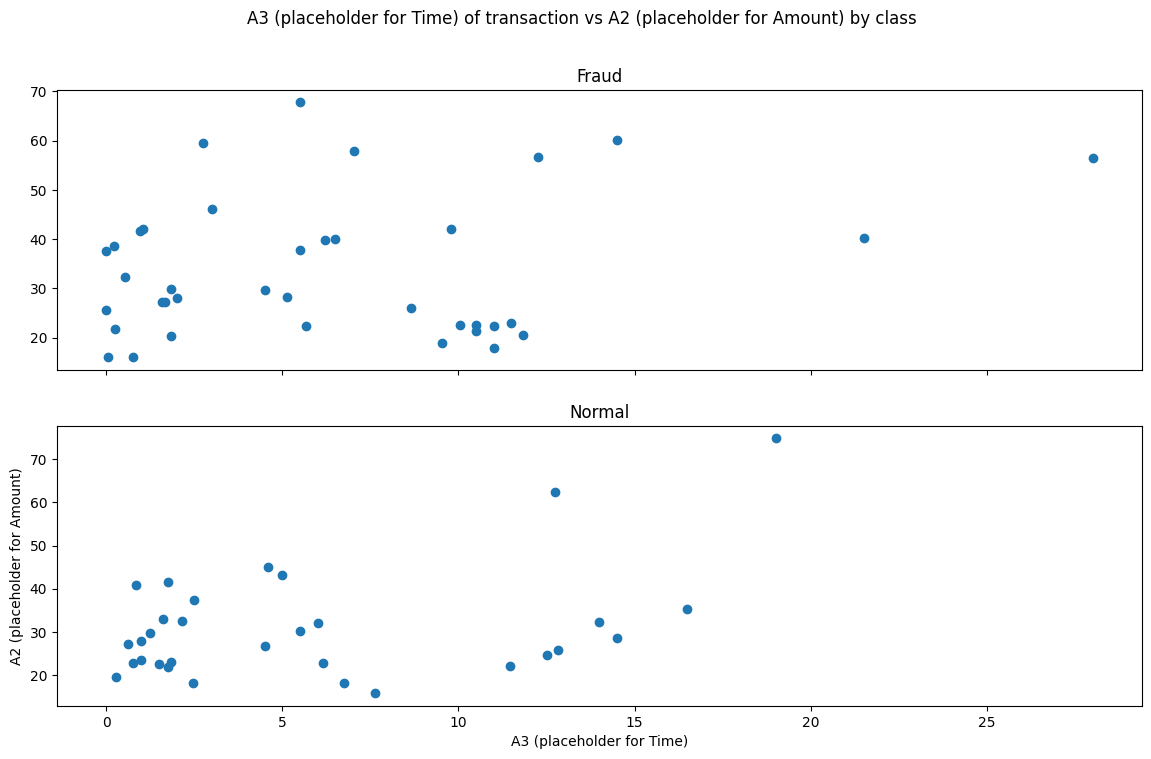

In [66]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('A3 (placeholder for Time) of transaction vs A2 (placeholder for Amount) by class')
ax1.scatter(fraud.A3, fraud.A2)
ax1.set_title('Fraud')
ax2.scatter(normal.A3, normal.A2)
ax2.set_title('Normal')
plt.xlabel('A3 (placeholder for Time)')
plt.ylabel('A2 (placeholder for Amount)')
plt.show()

In [67]:
Fraud = data[data['Class'] == 1]
Valid = data[data['Class'] == 0]

# Check if Valid is empty to prevent ZeroDivisionError when calculating outlier_fraction
if len(Valid) == 0 and len(Fraud) > 0:
    outlier_fraction = 1.0 # All sampled data is fraud
elif len(Valid) == 0 and len(Fraud) == 0:
    outlier_fraction = 0.0 # No data to sample
else:
    outlier_fraction = len(Fraud) / float(len(Fraud) + len(Valid)) # Corrected to be a proportion of total sampled data

print(f"Outlier Fraction (proportion of fraud in sample): {outlier_fraction}")
print(f"Fraud Cases: {len(Fraud)}")
print(f"Valid Cases: {len(Valid)}")

Outlier Fraction (proportion of fraud in sample): 0.5507246376811594
Fraud Cases: 38
Valid Cases: 31


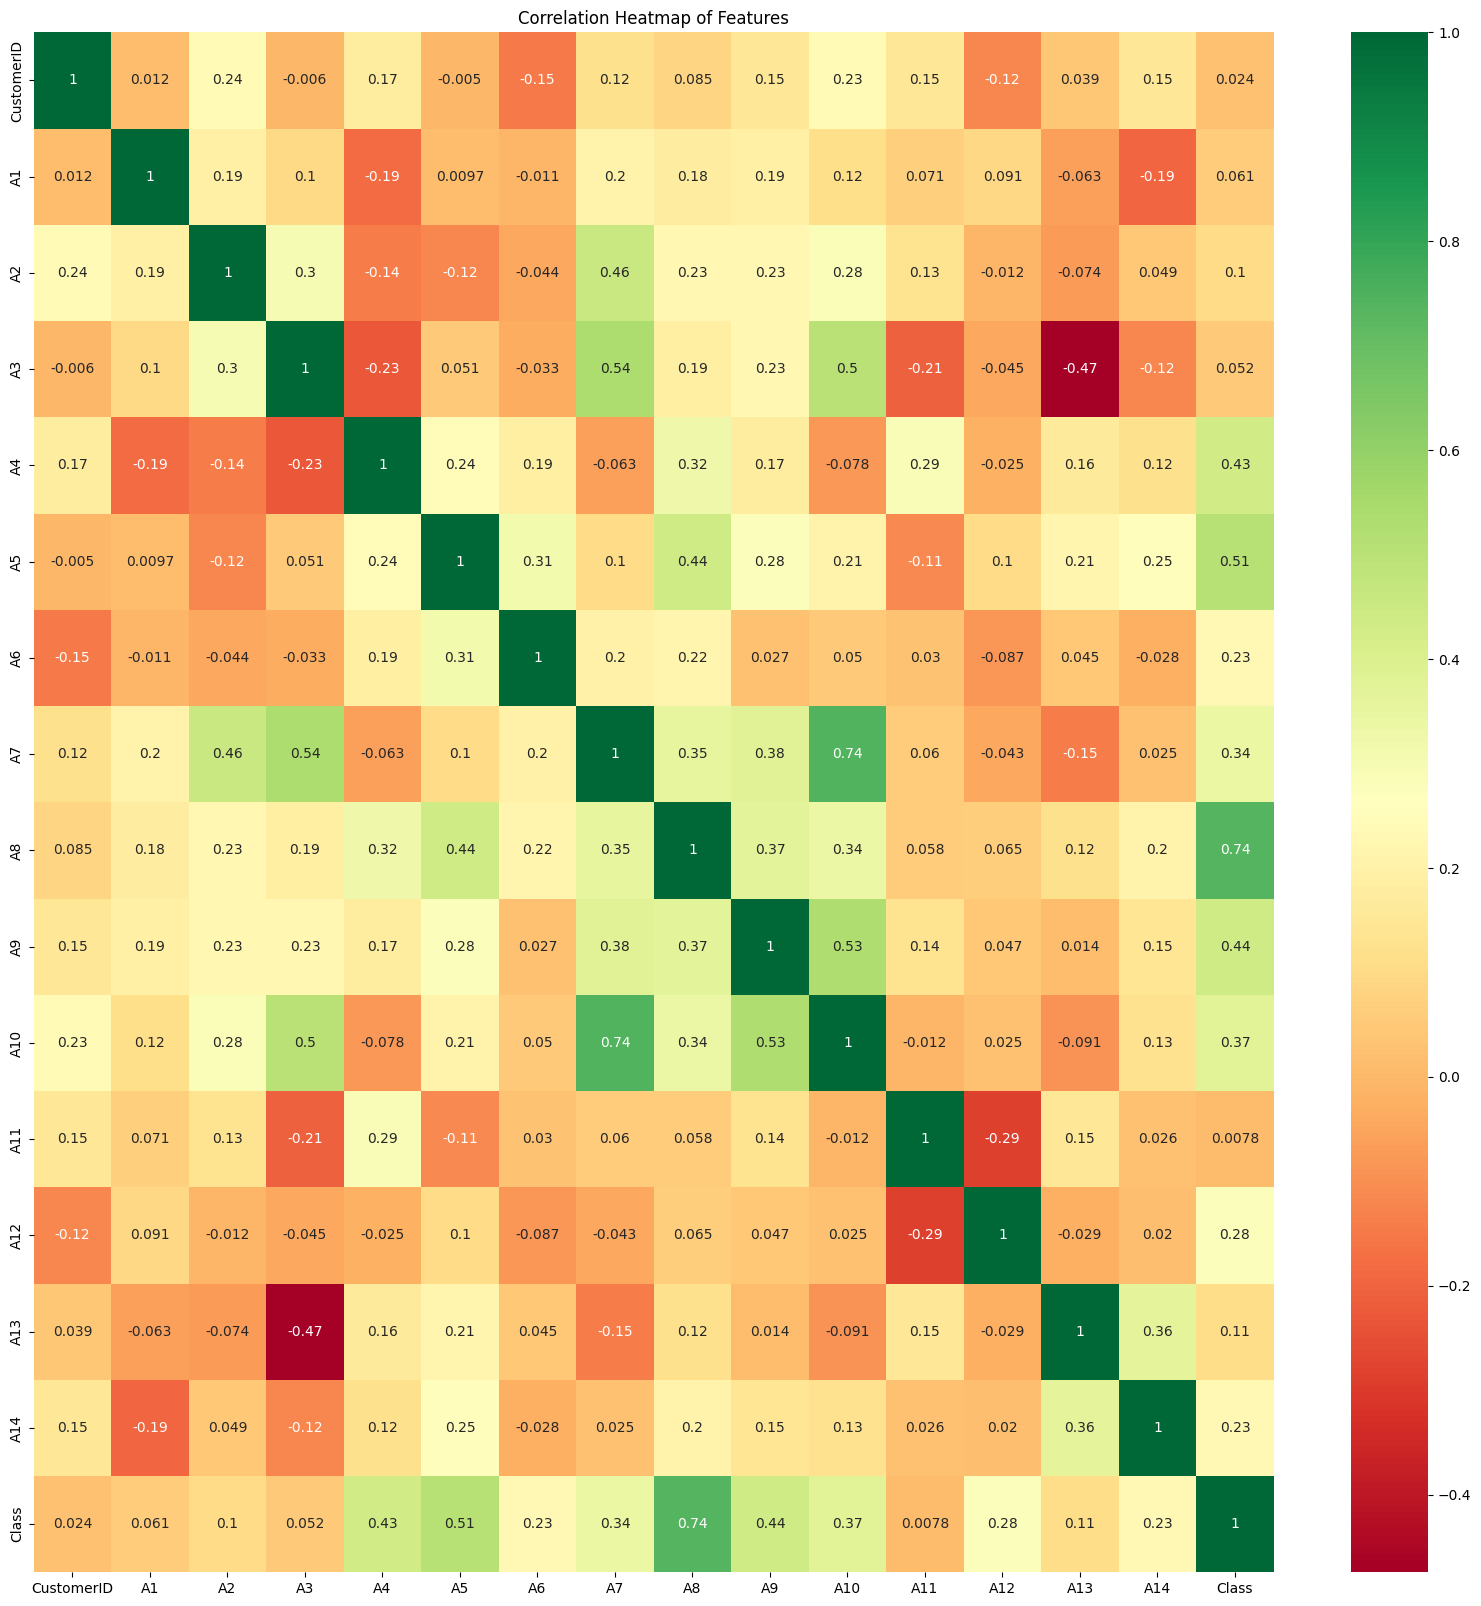

In [68]:
# Get correlations of each feature in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20, 20))
# Plot heat map
g = sns.heatmap(data[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.title('Correlation Heatmap of Features')
plt.show()

In [69]:
columns = data.columns.tolist()
# Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["Class"]]
# Store the variable we are predicting
target = "Class"
# Define a random state
state = np.random.RandomState(42)
X = data[columns]
Y = data[target]

# Note: X_outliers from the original context (state.uniform) seems to be a placeholder/example
# for generating synthetic outliers, not directly used in the model fitting in the provided snippet.
# It's not part of standard IsolationForest or LOF input, so I'll omit it as it's not used.

print(f"Shape of X (features): {X.shape}")
print(f"Shape of Y (target): {Y.shape}")

Shape of X (features): (69, 15)
Shape of Y (target): (69,)


In [71]:
classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=min(outlier_fraction, 0.5) if len(X) > 1 else 0.0, # Cap contamination at 0.5, handle single sample case
        random_state=state,
        verbose=0
    ),
    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=min(20, len(X) - 1) if len(X) > 1 else 1, # Ensure n_neighbors < n_samples_fit
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        contamination=min(outlier_fraction, 0.5) if len(X) > 1 else 0.0 # Cap contamination at 0.5, handle single sample case
    )
}

# Check if X is too small for models that require multiple samples
if len(X) < 2:
    print("\nSkipping anomaly detection models: Not enough samples for meaningful analysis (less than 2 samples).")
else:
    n_outliers = len(Fraud)
    for i, (clf_name, clf) in enumerate(classifiers.items()):
        print(f"\n--- Running {clf_name} ---")
        # Fit the data and tag outliers
        if clf_name == "Local Outlier Factor":
            y_pred = clf.fit_predict(X)
            scores_prediction = clf.negative_outlier_factor_
        else:
            clf.fit(X)
            scores_prediction = clf.decision_function(X)
            y_pred = clf.predict(X)

        # Reshape the prediction values to 0 for Valid transactions, 1 for Fraud transactions
        y_pred[y_pred == 1] = 0
        y_pred[y_pred == -1] = 1

        n_errors = (y_pred != Y).sum()

        # Run Classification Metrics
        print(f"{clf_name}: Number of errors = {n_errors}")
        print("Accuracy Score:")
        print(accuracy_score(Y, y_pred))
        print("Classification Report:")
        print(classification_report(Y, y_pred))


--- Running Isolation Forest ---
Isolation Forest: Number of errors = 36
Accuracy Score:
0.4782608695652174
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        31
           1       0.53      0.47      0.50        38

    accuracy                           0.48        69
   macro avg       0.48      0.48      0.48        69
weighted avg       0.48      0.48      0.48        69


--- Running Local Outlier Factor ---
Local Outlier Factor: Number of errors = 36
Accuracy Score:
0.4782608695652174
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        31
           1       0.53      0.47      0.50        38

    accuracy                           0.48        69
   macro avg       0.48      0.48      0.48        69
weighted avg       0.48      0.48      0.48        69

